Generate a random single-qubit pure state (i.e., choose a and b, say as a = $N_0$(0, 1) + i $N_1$(0, 1), where $N$(0, 1) is Gaussian distribution with zero mean
and unit standard deviation.)

|ψ⟩ = α |0⟩ + β |1⟩, with |α|² + |β|² = 1.

Perapre 100 such random states and apply repeated projective measurements on this state in the computational (Z) basis. Plot the distribution of |α|² with the random number realization.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm       # for matrix exponentiation

In [ ]:
# Number of random states
num_states = 100

Normalize

$α = \frac{α}{|α|² + |β|²}, \quad  β = \frac{β}{|α|² + |β|²}$

In [ ]:
alpha_probs = []

# Generate random states
for _ in range(num_states):
    # generate random numbers from a normal (Gaussian) distribution with mean 0 and variance 1.
    a = np.random.normal(0, 1) + 1j * np.random.normal(0, 1)
    b = np.random.normal(0, 1) + 1j * np.random.normal(0, 1)
    
    # Normalize
    norm = np.sqrt(np.abs(a)**2 + np.abs(b)**2)
    alpha, beta = a / norm, b / norm

    # Store probability of |0>
    alpha_probs.append(np.abs(alpha)**2)

np_alpha_probs = np.array(alpha_probs)

np_alpha_probs

array([0.96101289, 0.92948373, 0.64853097, 0.93156639, 0.20561373,
       0.72756314, 0.70723654, 0.79295178, 0.92867478, 0.13991623,
       0.17383454, 0.41111828, 0.51924287, 0.47808785, 0.6286342 ,
       0.83529204, 0.52644896, 0.98393761, 0.05591533, 0.60054374,
       0.05943752, 0.13862241, 0.57909769, 0.36400409, 0.98055714,
       0.97127892, 0.29781169, 0.12595424, 0.05868195, 0.61329469,
       0.46274956, 0.62313759, 0.6562965 , 0.49298001, 0.78479416,
       0.01025724, 0.8715065 , 0.92543742, 0.3280737 , 0.78902438,
       0.71276322, 0.50878798, 0.89001562, 0.86071783, 0.47899089,
       0.47112297, 0.66458095, 0.0607528 , 0.17758367, 0.2730926 ,
       0.6784923 , 0.49323031, 0.25686982, 0.68521889, 0.72325647,
       0.47539532, 0.57708674, 0.91806706, 0.10719986, 0.42996363,
       0.23962791, 0.53287705, 0.41450505, 0.61432651, 0.7086034 ,
       0.74527388, 0.49621315, 0.75688702, 0.37682916, 0.9593659 ,
       0.86364427, 0.70464231, 0.50205228, 0.06969071, 0.42419

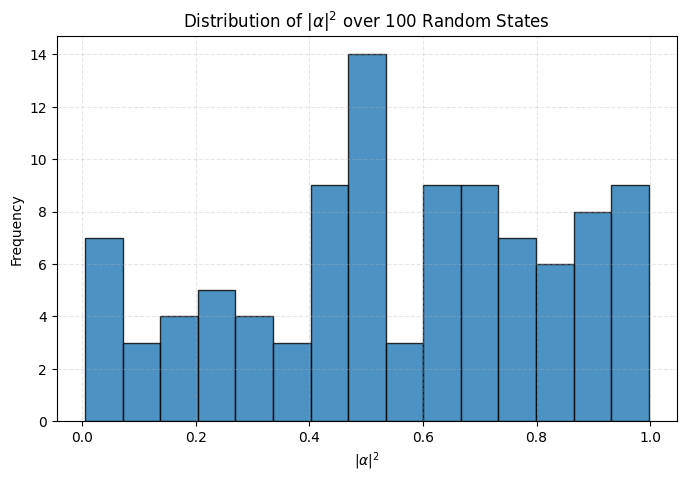

In [ ]:
# Plot histogram of |α|^2 distribution
plt.figure(figsize=(8, 5))
plt.hist(np_alpha_probs, bins=15, edgecolor="black", alpha=0.8)     # aplha is for opacity
plt.title(r"Distribution of $|\alpha|^2$ over 100 Random States")
plt.xlabel(r"$|\alpha|^2$")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

Prepare the quantum state |0⟩. Evolve it under the Hamiltonian H = $σ_x$, i.e.

|ψ(t)⟩ = $e^{-iHt}$ |0⟩.

(Hint: express H in its spectral decomposition 

$H = \sum_i e_i \, |e_i\rangle \langle e_i|$ , then show $|ψ(t)⟩ = \sum_i e^{-ie_it} |e_i\rangle \langle e_i|ψ(0)⟩$)

Task: Plot the overlap $|⟨ψ(t)|ψ(0)⟩|^2$ as a function of t.

In [ ]:

# Initial state |0>
psi0 = np.array([1, 0], dtype=complex)

# Pauli-X Hamiltonian
sigma_x = np.array([[0, 1],
                    [1, 0]], dtype=complex)

# Time range
t_vals = np.linspace(0, 10, 200)

In [ ]:
overlaps = []

for t in t_vals:
    # Time evolution operator: U(t) = exp(-iHt)
    U_t = expm(-1j * sigma_x * t)
    
    # Evolved state
    psi_t = U_t @ psi0       # Matrix-vector product
    
    # Overlap with initial state
    overlap = np.vdot(psi0, psi_t)      # <ψ(0)|ψ(t)>
    overlaps.append(np.abs(overlap)**2)

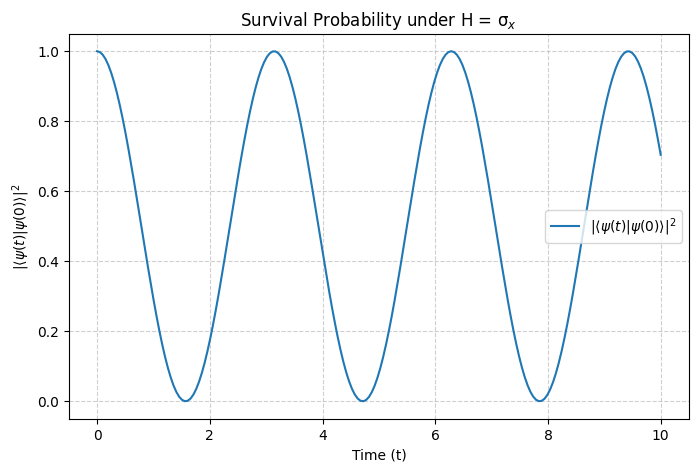

In [19]:
# Plot
plt.figure(figsize=(8,5))
plt.plot(t_vals, overlaps, label=r"$|\langle \psi(t)|\psi(0)\rangle|^2$")
plt.title("Survival Probability under H = σ$_x$")
plt.xlabel("Time (t)")
plt.ylabel(r"$|\langle \psi(t)|\psi(0)\rangle|^2$")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()